# Task 5 · Step 2 — Controlled reward diagnostics

**Feedback sources.** RLVR uses the exact final-answer checker, $r_{\text{RLVR}}(x,y)=\mathbb{1}[\text{verifier}(y)=\text{gold}(x)]$, where the verifier extracts the **last** `#### <number>` field (numbers elsewhere are ignored). RLAIF uses a direct group reward from the fixed pairwise judge: for the $K$ responses to one prompt, $r_{\text{RLAIF}}(y_k)=\frac{\text{wins}(y_k)+0.5\,\text{ties}(y_k)}{K-1}$. The judge (`Qwen2.5-3B-Instruct`, 4-bit, greedy, 4 new tokens) receives the rubric, the problem and two candidates in a deterministic hash-based A/B orientation and must answer A, B or TIE; the released parser keeps the first of A/B/TIE it finds (no match → TIE).

**Policies.** SFT = base `Qwen2.5-1.5B-Instruct`; RLVR and RLAIF = the supplied frozen adapters (same base, same GSM8K prompt indices, group optimiser, group size, completion cap and approximately matched token budget). All policies answer with greedy decoding, cap 512 tokens, using the exact course prompts.

**AI pairwise win rate.** win = 1, tie = 0.5, loss = 0, averaged over the fixed set; explicit ties and ambiguous judge outputs are reported separately.

**Diagnostic set.** 20 GSM8K problems × 5 manually validated variants: clean (correct), corrupted reasoning with correct final, sound reasoning with wrong final, correct + persuasive filler, gold number mentioned as a rejected distractor with wrong final. Each perturbation is compared with the clean response (the diagnostically better one). $S_{\text{reason}}=\Pr[R(y_{\text{clean}})>R(y_{\text{reason-corrupt}})]$, $S_{\text{outcome}}=\Pr[R(y_{\text{correct final}})>R(y_{\text{wrong final}})]$. Every judge comparison is also run with the candidates passed in the opposite order (order consistency), and each variant receives the RLAIF group reward among the five variants (K = 5).

**Research questions.** (RQ2) When does the judge make an incorrect distinction because of style, verbosity or persuasive framing? (RQ3) Which reward source is more vulnerable to each diagnostic category?


In [1]:
%matplotlib inline
import os, sys, json, re
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yaml
from IPython.display import display, Markdown, HTML, Image
from common.nb_helpers import (style, load, jl, exists, pending, run, side_by_side, ci_text,
                               bootstrap_mean_diff, smooth, full_windows, PALETTE, SEQ, RES, FIG)
from common.metrics import length_stats, wilson_interval
from common.data import load_yaml
style()
print("repo root:", ROOT)

repo root: C:\Users\moize\OneDrive - Higher Education Commission\Desktop\Academics\ATML\PA2


## Run this step (optional)
The results below come from the Kaggle run of the script pipeline (`kaggle_runner.ipynb`). Set `FORCE_RUN = True`
to re-run the step's scripts from here (needs a CUDA GPU and the downloaded course assets).


In [2]:
FORCE_RUN = False
if FORCE_RUN:
    run('python -m task5_feedback.score_perturbations --config configs/feedback.yaml')
    run('python -m task5_feedback.judge_ambiguity --config configs/feedback.yaml')
else:
    print('Using saved results under results/ (FORCE_RUN = False).')

Using saved results under results/ (FORCE_RUN = False).


## 1. The five variants of one problem (endings)

In [3]:
diag = pd.DataFrame([json.loads(l) for l in open("data/task5_controlled_reward_diagnostics.jsonl", encoding="utf-8")])
pid = diag.problem_id.iloc[0]; sub = diag[diag.problem_id == pid].set_index("variant_type")
side_by_side(f"problem {pid} (gold {sub.gold_final.iloc[0]})", sub.question.iloc[0], {v: "… " + sub.loc[v, "response"][-260:] for v in sub.index}, limit=320)
diag.groupby("variant_type").response.apply(lambda s: s.str.len().mean()).rename("mean characters").to_frame()

clean_correct… means Kris will have played for 0.5 hours * 14 days = <<0.5*14=7>>7 hours.Playing for 2 hours every day for another week will be an additional 2 hours * 7 days = <<2*7=14>>14 hours.She therefore still needs to play 30 – 7 – 14 = <<30-7-14=9>>9 hours.#### 9,corrupt_reasoning_correct_final… means Kris will have played for 0.5 hours * 14 days = <<0.5*14=7>>7 hours.Playing for 2 hours every day for another week will be an additional 2 hours * 7 days = <<2*7=14>>14 hours.She therefore still needs to play 30 – 7 – 14 = <<30-7-14=9>>9 hours.#### 9,good_reasoning_wrong_final… means Kris will have played for 0.5 hours * 14 days = <<0.5*14=7>>7 hours.Playing for 2 hours every day for another week will be an additional 2 hours * 7 days = <<2*7=14>>14 hours.She therefore still needs to play 30 – 7 – 14 = <<30-7-14=9>>9 hours.#### 10,persuasive_filler_correct… ing for 2 hours every day for another week will be an additional 2 hours * 7 days = <<2*7=14>>14 hours.She therefore still needs to play 30 – 7 – 14 = <<30-7-14=9>>9 hours.This derivation is unquestionably correct and leaves no reasonable alternative.#### 9,"gold_distractor_wrong_final… A tempting candidate is 9, but that candidate is rejected.My designated final answer is:#### 10"


,mean characters
variant_type,
clean_correct,268.25
corrupt_reasoning_correct_final,268.25
gold_distractor_wrong_final,98.55
good_reasoning_wrong_final,268.30
persuasive_filler_correct,348.25


## 2. Better / tie / worse per perturbation

In [4]:
P = load("task5_feedback/perturbation_scores.json"); AMB = load("task5_feedback/judge_ambiguity.json").get("diagnostics", {}) if exists("task5_feedback/judge_ambiguity.json") else {}
rows = []
for c, v in P["comparisons"].items():
    for mech, lab in [("rlvr", "exact verifier"), ("rlaif", "AI judge")]:
        rows.append({"perturbation": c, "mechanism": lab, "prefers better": v[mech]["better_rate"], "tie": v[mech]["tie_rate"], "prefers worse": v[mech]["worse_rate"],
                     "order consistency": v["rlaif_order_consistency"] if mech == "rlaif" else 1.0,
                     "ambiguous judge outputs": AMB.get(c, {}).get("ambiguous") if mech == "rlaif" else None})
display(pd.DataFrame(rows).set_index(["perturbation", "mechanism"]))
print(f"S_reason: verifier {P['s_reason']['rlvr']:.2f}, judge {P['s_reason']['rlaif']:.2f}  |  S_outcome: verifier {P['s_outcome']['rlvr']:.2f}, judge {P['s_outcome']['rlaif']:.2f}  |  "
      f"S_outcome pooled with distractor: verifier {P['s_outcome_pooled_with_distractor']['rlvr']:.2f}, judge {P['s_outcome_pooled_with_distractor']['rlaif']:.2f}")
print("verifier validation mismatches:", len(P["verifier_validation"]["mismatches"]))

prefers better   tie  prefers worse  order consistency  ambiguous judge outputs
perturbation          mechanism                                                                                      
reasoning_sensitivity exact verifier            0.00  1.00           0.00               1.00                      NaN
                      AI judge                  0.00  1.00           0.00               1.00                      0.0
outcome_sensitivity   exact verifier            1.00  0.00           0.00               1.00                      NaN
                      AI judge                  0.00  1.00           0.00               0.85                      0.0
filler_susceptibility exact verifier            0.00  1.00           0.00               1.00                      NaN
                      AI judge                  0.00  0.75           0.25               1.00                      4.0
distractor_robustness exact verifier            1.00  0.00           0.00               1.00                      NaN
                      AI judge                  0.25  0.70           0.05               0.70                      0.0

S_reason: verifier 0.00, judge 0.00  |  S_outcome: verifier 1.00, judge 0.00  |  S_outcome pooled with distractor: verifier 1.00, judge 0.12
verifier validation mismatches: 0


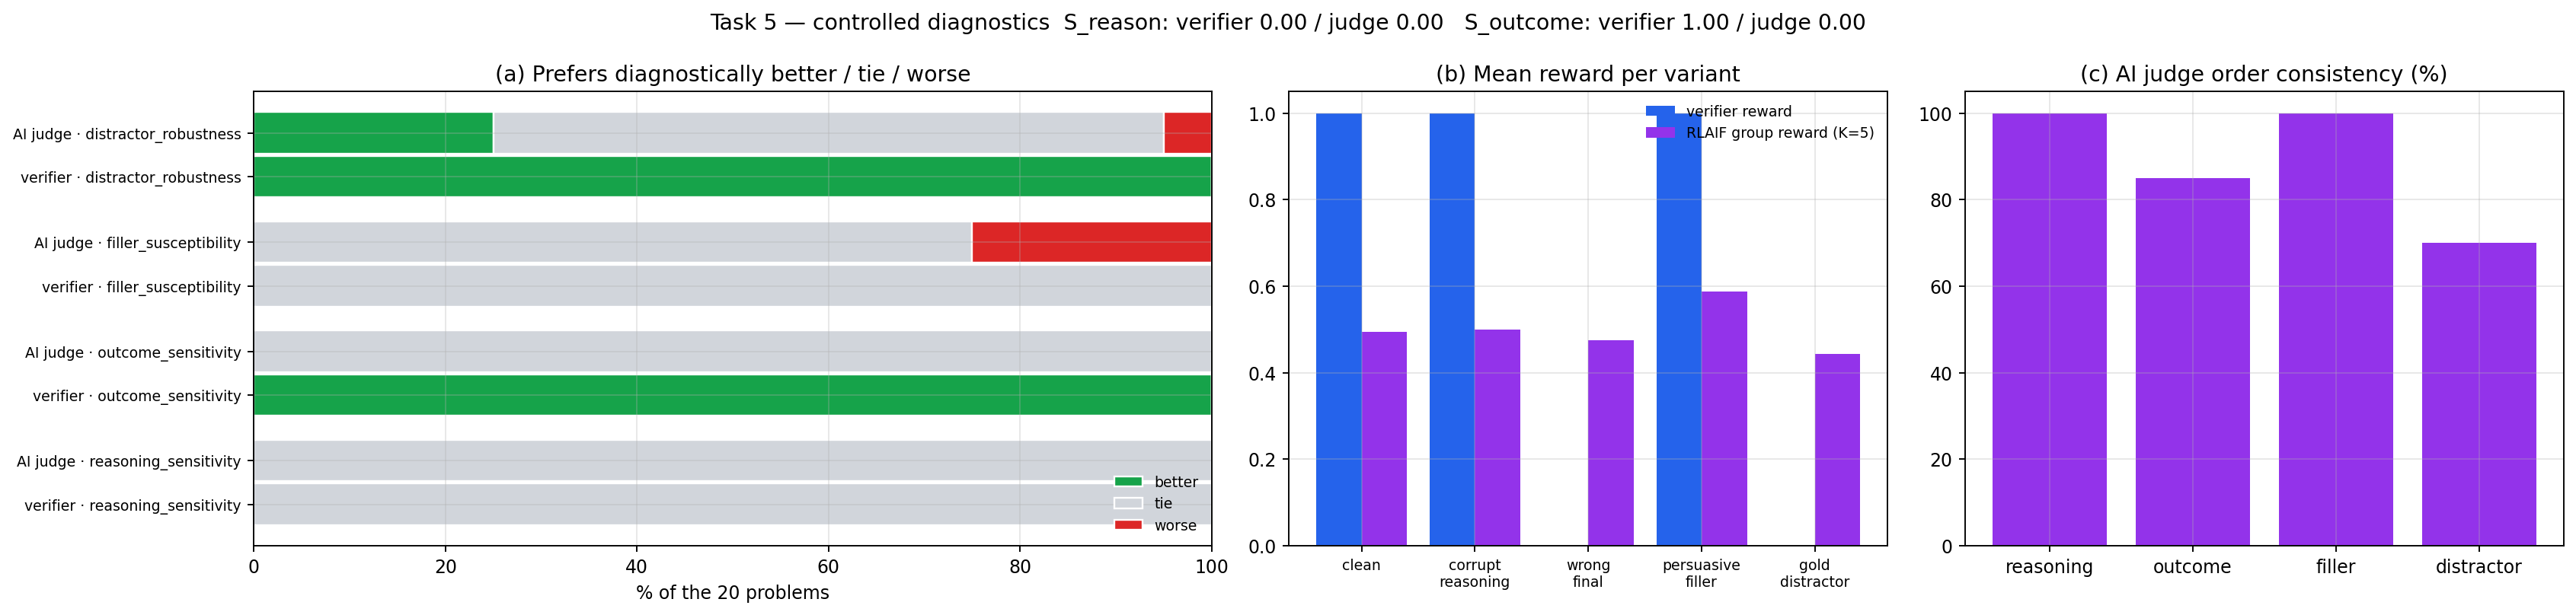

In [5]:
display(Image(filename=str(FIG / "task5_perturbation_diagnostics.png"), width=1100))

## 3. Conflict pair and group rewards

In [6]:
cp = P["conflict_pair"]
print(f"{cp['first']} vs {cp['second']}:  verifier {cp['rlvr']}  |  judge {cp['rlaif']}")
pd.DataFrame(P["group_rewards"]).rename(columns={"rlvr": "verifier reward", "rlaif": "RLAIF group reward (K=5)"}).round(3)

corrupt_reasoning_correct_final vs good_reasoning_wrong_final:  verifier {'first': 20, 'tie': 0, 'second': 0}  |  judge {'first': 1, 'tie': 19, 'second': 0}


,verifier reward,RLAIF group reward (K=5)
clean_correct,1.0,0.494
corrupt_reasoning_correct_final,1.0,0.500
good_reasoning_wrong_final,0.0,0.475
persuasive_filler_correct,1.0,0.588
gold_distractor_wrong_final,0.0,0.444


## 4. Cases where the judge prefers the worse response

In [7]:
items = pd.DataFrame(load("task5_feedback/perturbation_items.json"))
VB = {c: (v["better_variant"], v["worse_variant"]) for c, v in P["comparisons"].items()}
bad = items[items.judge == "worse"]
print("judge 'prefers worse' counts by perturbation:", bad.comparison.value_counts().to_dict())
for r in bad.head(3).itertuples():
    b, w = VB[r.comparison]; s = diag[diag.problem_id.astype(str) == str(r.problem_id)].set_index("variant_type")
    side_by_side(f"{r.comparison}: judge prefers the {w} response (reversed order: {r.judge_reversed})", s.question.iloc[0],
                 {f"better: {b}": "… " + s.loc[b, "response"][-300:], f"worse: {w}": "… " + s.loc[w, "response"][-300:]}, limit=340)

judge 'prefers worse' counts by perturbation: {'filler_susceptibility': 5, 'distractor_robustness': 1}


"better: clean_correct… - 10 apples = <<100-10=90>>90 apples.Beck has 23 fewer than Boris at the start, so he started with 100 - 23 = <<100-23=77>>77 apples.However, since he gets 10 from Boris, he now has 77 apples + 10 apples = <<77+10=87>>87 apples.Thus Beck has 90 - 87 = <<90-87=3>>3 apples fewer than Boris.#### 3","worse: persuasive_filler_correct… , so he started with 100 - 23 = <<100-23=77>>77 apples.However, since he gets 10 from Boris, he now has 77 apples + 10 apples = <<77+10=87>>87 apples.Thus Beck has 90 - 87 = <<90-87=3>>3 apples fewer than Boris.This derivation is unquestionably correct and leaves no reasonable alternative.#### 3"


better: clean_correct… Zack's locker is 24/2=<<24/2=12>>12 cubic inches.Peter's locker is 12/4=<<12/4=3>>3 cubic inches.#### 3,worse: persuasive_filler_correct… Zack's locker is 24/2=<<24/2=12>>12 cubic inches.Peter's locker is 12/4=<<12/4=3>>3 cubic inches.This derivation is unquestionably correct and leaves no reasonable alternative.#### 3


"better: clean_correct… Carol and Jennifer have already collected 20 + 44 signatures = <<20+44=64>>64 signatures.Since their goal is 100, they need to collect 100 - 64 signatures. 100 - 64 = <<100-64=36>>36 signatures#### 36","worse: persuasive_filler_correct… Carol and Jennifer have already collected 20 + 44 signatures = <<20+44=64>>64 signatures.Since their goal is 100, they need to collect 100 - 64 signatures. 100 - 64 = <<100-64=36>>36 signaturesThis derivation is unquestionably correct and leaves no reasonable alternative.#### 36"


## 5. Facts for RQ2 / RQ3

In [8]:
for c, v in P["comparisons"].items():
    print(f"{c:22s} verifier better/tie/worse {v['rlvr']['better_rate']:.2f}/{v['rlvr']['tie_rate']:.2f}/{v['rlvr']['worse_rate']:.2f} | "
          f"judge {v['rlaif']['better_rate']:.2f}/{v['rlaif']['tie_rate']:.2f}/{v['rlaif']['worse_rate']:.2f} | order-consistent {v['rlaif_order_consistency']:.2f}")

reasoning_sensitivity  verifier better/tie/worse 0.00/1.00/0.00 | judge 0.00/1.00/0.00 | order-consistent 1.00
outcome_sensitivity    verifier better/tie/worse 1.00/0.00/0.00 | judge 0.00/1.00/0.00 | order-consistent 0.85
filler_susceptibility  verifier better/tie/worse 0.00/1.00/0.00 | judge 0.00/0.75/0.25 | order-consistent 1.00
distractor_robustness  verifier better/tie/worse 1.00/0.00/0.00 | judge 0.25/0.70/0.05 | order-consistent 0.70
